# 01 — Exploratory Data Analysis (EDA)
## Loan Default Prediction | Give Me Some Credit

**Mục tiêu notebook này:**
1. Hiểu phân phối của từng feature trong bối cảnh tài chính
2. Phát hiện outlier, missing values, và anomalies cần xử lý
3. Phân tích class imbalance và đặt vấn đề metric
4. Xác định correlation giữa features và target
5. Rút ra insights domain để thiết kế feature engineering 

> **Nguyên tắc:** Mọi biểu đồ đều phải có nhận xét kết nối với lý thuyết rủi ro tín dụng — không chỉ mô tả số liệu.


## 0. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
})
PALETTE = {'default': '#e74c3c', 'non_default': '#2ecc71', 'neutral': '#3498db'}

print("Libraries loaded.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Libraries loaded.
pandas 3.0.2 | numpy 2.4.4


## 1. Load Data

Dataset **Give Me Some Credit** từ Kaggle — 150,000 hồ sơ vay vốn tại Mỹ, được thu thập để xây dựng mô hình credit scoring.

**Cấu trúc:** 10 features tài chính + 1 binary target `SeriousDlqin2yrs`


In [2]:
DATA_PATH = Path('../data/raw/cs-training.csv')

df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Columns & dtypes:")
print(df.dtypes)


Shape: (150000, 11)
Memory usage: 13.2 MB

Columns & dtypes:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


In [3]:
# Preview 5 rows
df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Summary Statistics

Bảng tổng hợp gồm: missing%, mean, median, std, min, max, skewness, kurtosis.

**Tại sao cần skewness và kurtosis?**
- Skewness cao → phân phối lệch → cần log-transform hoặc robust scaling
- Kurtosis cao → heavy tails, nhiều extreme values → outlier treatment cần cẩn thận


In [4]:
def get_summary(df):
    """Summary statistics đầy đủ cho EDA."""
    return pd.DataFrame({
        'missing_pct': df.isnull().mean() * 100,
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(numeric_only=True),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'skewness': df.skew(numeric_only=True),
        'kurtosis': df.kurt(numeric_only=True),
        'pct_1': df.quantile(0.01),
        'pct_99': df.quantile(0.99),
    }).round(4)

summary = get_summary(df)
summary


,missing_pct,mean,median,std,min,max,skewness,kurtosis,pct_1,pct_99
SeriousDlqin2yrs,0.0000,0.0668,0.0000,0.2497,0.0,1.0,3.4689,10.0331,0.0,1.000
RevolvingUtilizationOfUnsecuredLines,0.0000,6.0484,0.1542,249.7554,0.0,50708.0,97.6316,14544.7134,0.0,1.093
age,0.0000,52.2952,52.0000,14.7719,0.0,109.0,0.1890,-0.4947,24.0,87.000
NumberOfTime30-59DaysPastDueNotWorse,0.0000,0.4210,0.0000,4.1928,0.0,98.0,22.5971,522.3765,0.0,4.000
DebtRatio,0.0000,353.0051,0.3665,2037.8185,0.0,329664.0,95.1578,13734.2889,0.0,4979.040
MonthlyIncome,19.8207,6670.2212,5400.0000,14384.6742,0.0,3008750.0,114.0403,19504.7054,0.0,25000.000
NumberOfOpenCreditLinesAndLoans,0.0000,8.4528,8.0000,5.1460,0.0,58.0,1.2153,3.0911,0.0,24.000
NumberOfTimes90DaysLate,0.0000,0.2660,0.0000,4.1693,0.0,98.0,23.0873,537.7389,0.0,3.000
NumberRealEstateLoansOrLines,0.0000,1.0182,1.0000,1.1298,0.0,54.0,3.4825,60.4768,0.0,4.000
NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.2404,0.0000,4.1552,0.0,98.0,23.3317,545.6827,0.0,2.000


## 3. Phân tích Target — Class Imbalance

`SeriousDlqin2yrs = 1` nghĩa là khách hàng đã từng **trễ thanh toán ≥ 90 ngày trong 2 năm** sau thời điểm thu thập dữ liệu.

### Tại sao class imbalance là vấn đề nghiêm trọng?

Dataset có ~6.7% positive cases. Nếu dùng **Accuracy** làm metric:
- Model "đoán tất cả 0" đạt Accuracy = 93.3% nhưng **Recall = 0%**
- Trong tín dụng, False Negative (bỏ sót người vỡ nợ) là thảm họa kinh doanh: ngân hàng mất toàn bộ số tiền cho vay
- **AUC-ROC** đo khả năng ranking (phân biệt defaulter vs non-defaulter) — độc lập với threshold và imbalance
- **F1-Score** cân bằng Precision và Recall — phù hợp để so sánh models ở threshold cố định


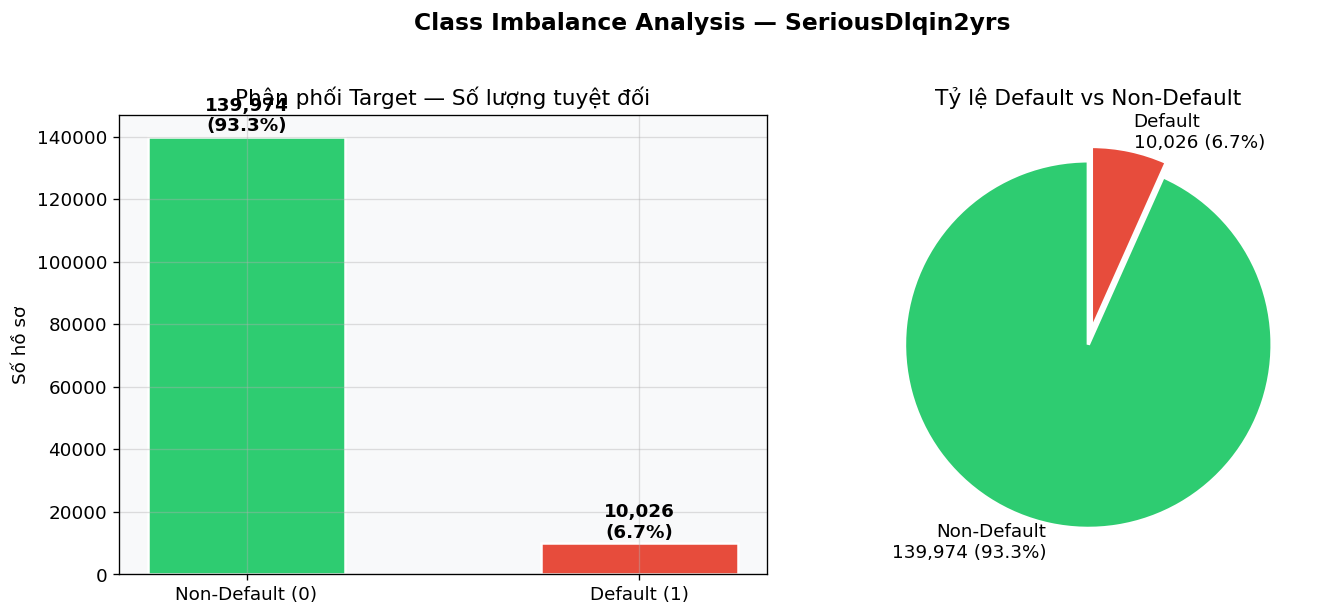


Imbalance ratio: 1:14.0
Scale_pos_weight cho XGBoost: 13.96


In [5]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Non-Default (0)', 'Default (1)'],
                   target_counts.values,
                   color=[PALETTE['non_default'], PALETTE['default']],
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Phân phối Target — Số lượng tuyệt đối')
axes[0].set_ylabel('Số hồ sơ')
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=[f'Non-Default\n{target_counts.iloc[0]:,} ({target_pct.iloc[0]:.1f}%)',
                    f'Default\n{target_counts.iloc[1]:,} ({target_pct.iloc[1]:.1f}%)'],
            colors=[PALETTE['non_default'], PALETTE['default']],
            explode=(0, 0.08),
            startangle=90,
            autopct='',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ lệ Default vs Non-Default')

plt.suptitle('Class Imbalance Analysis — SeriousDlqin2yrs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig_01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nImbalance ratio: 1:{target_counts.iloc[0]/target_counts.iloc[1]:.1f}")
print(f"Scale_pos_weight cho XGBoost: {target_counts.iloc[0]/target_counts.iloc[1]:.2f}")


## 4. Phân tích Missing Values

### Phân loại Missing theo cơ chế (quan trọng cho việc chọn imputation strategy):

| Loại | Ý nghĩa | Imputation phù hợp |
|------|---------|-------------------|
| **MCAR** (Missing Completely At Random) | Missing hoàn toàn ngẫu nhiên | Bất kỳ (median, mean, KNN) |
| **MAR** (Missing At Random) | Missing phụ thuộc vào features khác, không phụ thuộc giá trị của chính nó | KNN, model-based |
| **MNAR** (Missing Not At Random) | Missing phụ thuộc vào giá trị bị thiếu | Cần domain knowledge |

**Hypothesis:**
- `MonthlyIncome` (19.82% null): Người không có thu nhập ổn định (freelancer, thất nghiệp) ít khai báo — đây là **MNAR** hoặc **MAR**. KNN Imputer phù hợp hơn median vì nó khai thác correlation với age, DebtRatio.
- `NumberOfDependents` (2.62% null): Pattern ngẫu nhiên hơn — **MAR** hoặc **MCAR**. Median đủ.


Features có missing values:
                    count_missing  pct_missing    dtype
MonthlyIncome               29731    19.820667  float64
NumberOfDependents           3924     2.616000  float64


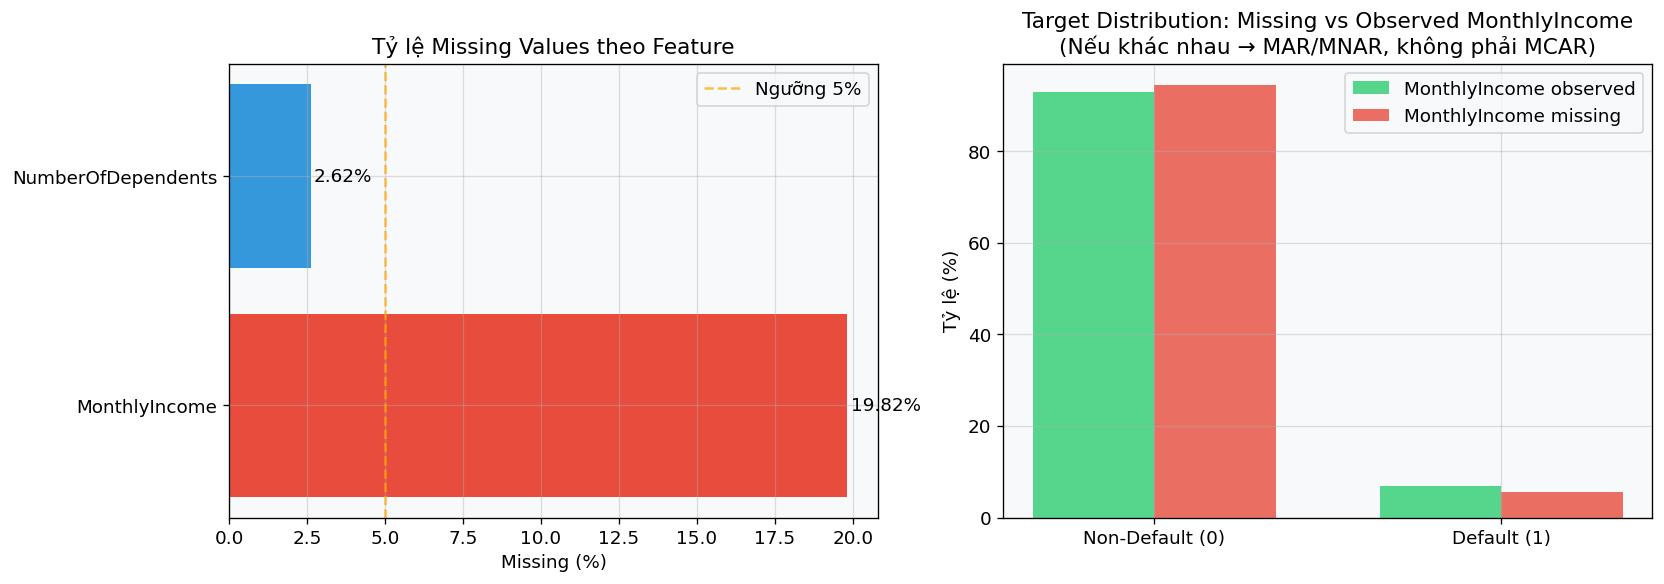


Chi-squared test (MonthlyIncome missing vs target):
  chi2 = 67.89, p-value = 0.0000
  → MAR/MNAR: missing KHÔNG independent với target (p<0.05)


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'count_missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100,
    'dtype': df.dtypes
}).query('count_missing > 0')

print("Features có missing values:")
print(missing.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart missing %
cols_missing = missing.index.tolist()
pcts = missing['pct_missing'].values
bars = axes[0].barh(cols_missing, pcts,
                    color=[PALETTE['default'] if p > 10 else PALETTE['neutral'] for p in pcts])
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Tỷ lệ Missing Values theo Feature')
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{pct:.2f}%', va='center')
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Ngưỡng 5%')
axes[0].legend()

# Missing pattern: so sánh target distribution giữa missing vs non-missing MonthlyIncome
missing_mask = df['MonthlyIncome'].isnull()
target_in_missing = df.loc[missing_mask, 'SeriousDlqin2yrs'].value_counts(normalize=True) * 100
target_in_observed = df.loc[~missing_mask, 'SeriousDlqin2yrs'].value_counts(normalize=True) * 100

x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, [target_in_observed.get(0,0), target_in_observed.get(1,0)],
            width, label='MonthlyIncome observed', color=PALETTE['non_default'], alpha=0.8)
axes[1].bar(x + width/2, [target_in_missing.get(0,0), target_in_missing.get(1,0)],
            width, label='MonthlyIncome missing', color=PALETTE['default'], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Non-Default (0)', 'Default (1)'])
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_title('Target Distribution: Missing vs Observed MonthlyIncome\n(Nếu khác nhau → MAR/MNAR, không phải MCAR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig_02_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

# Chi-squared test: missing indicator vs target
from scipy.stats import chi2_contingency
missing_indicator = df['MonthlyIncome'].isnull().astype(int)
ct = pd.crosstab(missing_indicator, df['SeriousDlqin2yrs'])
chi2, p_val, _, _ = chi2_contingency(ct)
print(f"\nChi-squared test (MonthlyIncome missing vs target):")
print(f"  chi2 = {chi2:.2f}, p-value = {p_val:.4f}")
print(f"  → {'MAR/MNAR: missing KHÔNG independent với target (p<0.05)' if p_val < 0.05 else 'MCAR: missing independent với target'}")


## 5. Univariate Analysis — Phân phối từng Feature

**Mục tiêu:** Hiểu hình dạng phân phối, phát hiện outlier cực đoan, và xác định cần transform gì trước khi đưa vào model.

**Domain context:**
- Features delinquency (30-59, 60-89, 90+ days) nên có phân phối **right-skewed** vì đa số người không trễ hạn
- `RevolvingUtilizationOfUnsecuredLines` nên có giá trị trong [0, 1] — giá trị >1 là anomaly
- `age` nên có lower bound hợp lý (≥18 cho phép vay), giá trị 0 là error


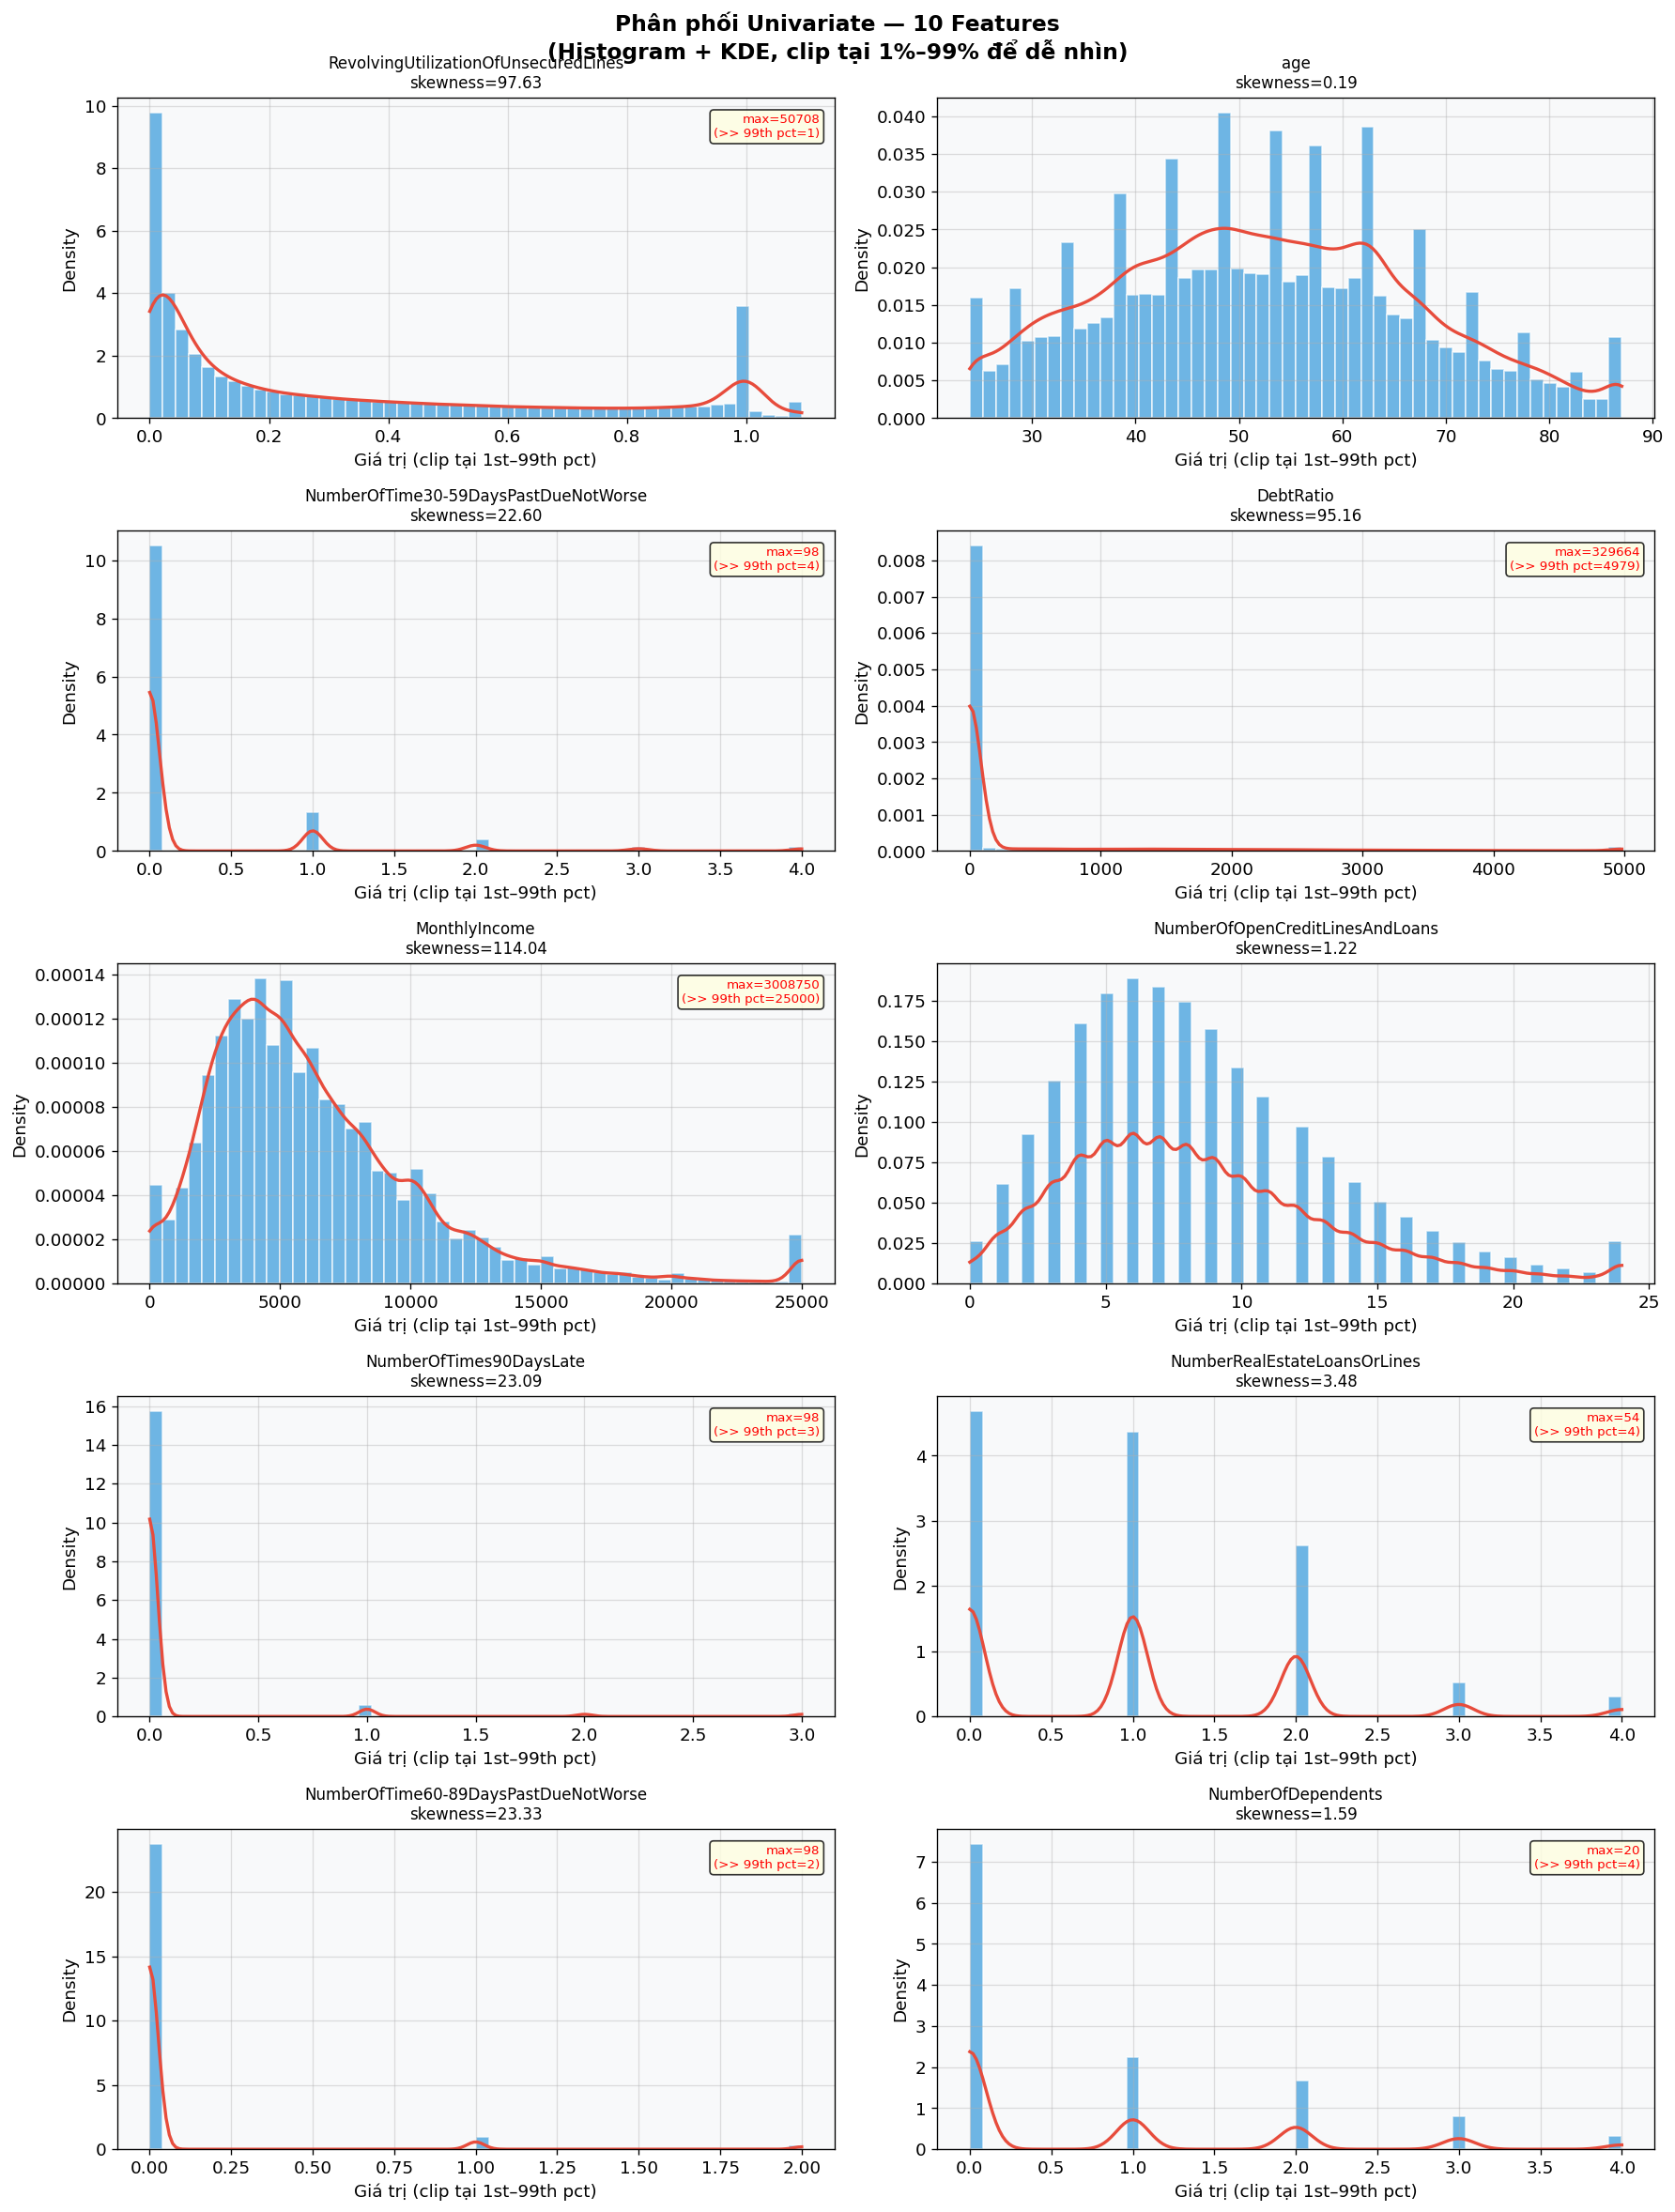

In [ ]:
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = df[col].dropna()
    ax = axes[i]

    # Clip extreme values for visualization
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data.clip(p1, p99)

    ax.hist(data_clipped, bins=50, color=PALETTE['neutral'], alpha=0.7,
            edgecolor='white', density=True)

    # KDE overlay
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(data_clipped)
        x_range = np.linspace(data_clipped.min(), data_clipped.max(), 200)
        ax.plot(x_range, kde(x_range), color='#e74c3c', linewidth=2, label='KDE')
    except Exception:
        pass

    skew_val = data.skew()
    ax.set_title(f'{col}\nskewness={skew_val:.2f}', fontsize=10)
    ax.set_xlabel('Giá trị (clip tại 1st–99th pct)')
    ax.set_ylabel('Density')

    # Annotation for outliers
    if data.max() > p99 * 3:
        ax.text(0.98, 0.95, f'max={data.max():.0f}\n(>> 99th pct={p99:.0f})',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='red',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Phân phối Univariate — 10 Features\n(Histogram + KDE, clip tại 1%–99% để dễ nhìn)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_03_univariate.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# Outlier summary — giá trị bất thường cần xử lý trong Phase 2
print("=== OUTLIER REPORT ===\n")

# age == 0
age_zero = (df['age'] == 0).sum()
print(f"age == 0: {age_zero} rows (nonsensical — không thể vay khi 0 tuổi → XÓA)")

# age < 18
age_minor = (df['age'] < 18).sum()
print(f"age < 18: {age_minor} rows")

# RevolvingUtilization > 1
util_gt1 = (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
util_extreme = (df['RevolvingUtilizationOfUnsecuredLines'] > 10).sum()
print(f"RevolvingUtilization > 1: {util_gt1} rows ({util_gt1/len(df)*100:.1f}%)")
print(f"RevolvingUtilization > 10: {util_extreme} rows — extreme outlier, cần capping")
        
# MonthlyIncome extremes
p99_income = df['MonthlyIncome'].quantile(0.99)
income_extreme = (df['MonthlyIncome'] > p99_income).sum()
print(f"MonthlyIncome > 99th pct ({p99_income:,.0f}): {income_extreme} rows → capping")
print(f"MonthlyIncome max: {df['MonthlyIncome'].max():,.0f} (>1M USD = suspicious)")

# Delinquency counts
for col in ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    p99 = df[col].quantile(0.99)
    extreme = (df[col] > p99).sum()
    max_val = df[col].max()
    print(f"{col}: max={max_val}, 99th pct={p99:.0f}, rows>{p99:.0f}: {extreme}")


=== OUTLIER REPORT ===

age == 0: 1 rows (nonsensical — không thể vay khi 0 tuổi → XÓA)
age < 18: 1 rows
RevolvingUtilization > 1: 3321 rows (2.2%)
RevolvingUtilization > 10: 241 rows — extreme outlier, cần capping
MonthlyIncome > 99th pct (25,000): 1168 rows → capping
MonthlyIncome max: 3,008,750 (>1M USD = suspicious)
NumberOfTimes90DaysLate: max=98, 99th pct=3, rows>3: 873
NumberOfTime30-59DaysPastDueNotWorse: max=98, 99th pct=4, rows>4: 850
NumberOfTime60-89DaysPastDueNotWorse: max=98, 99th pct=2, rows>2: 755


## 6. Bivariate Analysis — Feature vs Target

**Mục tiêu:** Xác định features nào có **discriminative power** cao — phân phối khác biệt rõ giữa defaulters (1) và non-defaulters (0).

**Domain context:**
- `NumberOfTimes90DaysLate` nên là predictor mạnh nhất: trễ >90 ngày là dấu hiệu severe financial distress
- `RevolvingUtilizationOfUnsecuredLines` cao → đang "maxed out" thẻ tín dụng → stress tài chính
- `age` trẻ → ít kinh nghiệm quản lý tài chính → risk cao hơn

**Statistical test:** Mann-Whitney U test (non-parametric, phù hợp với right-skewed distributions) để kiểm tra xem phân phối của feature có **statistically significantly khác nhau** giữa 2 class không.


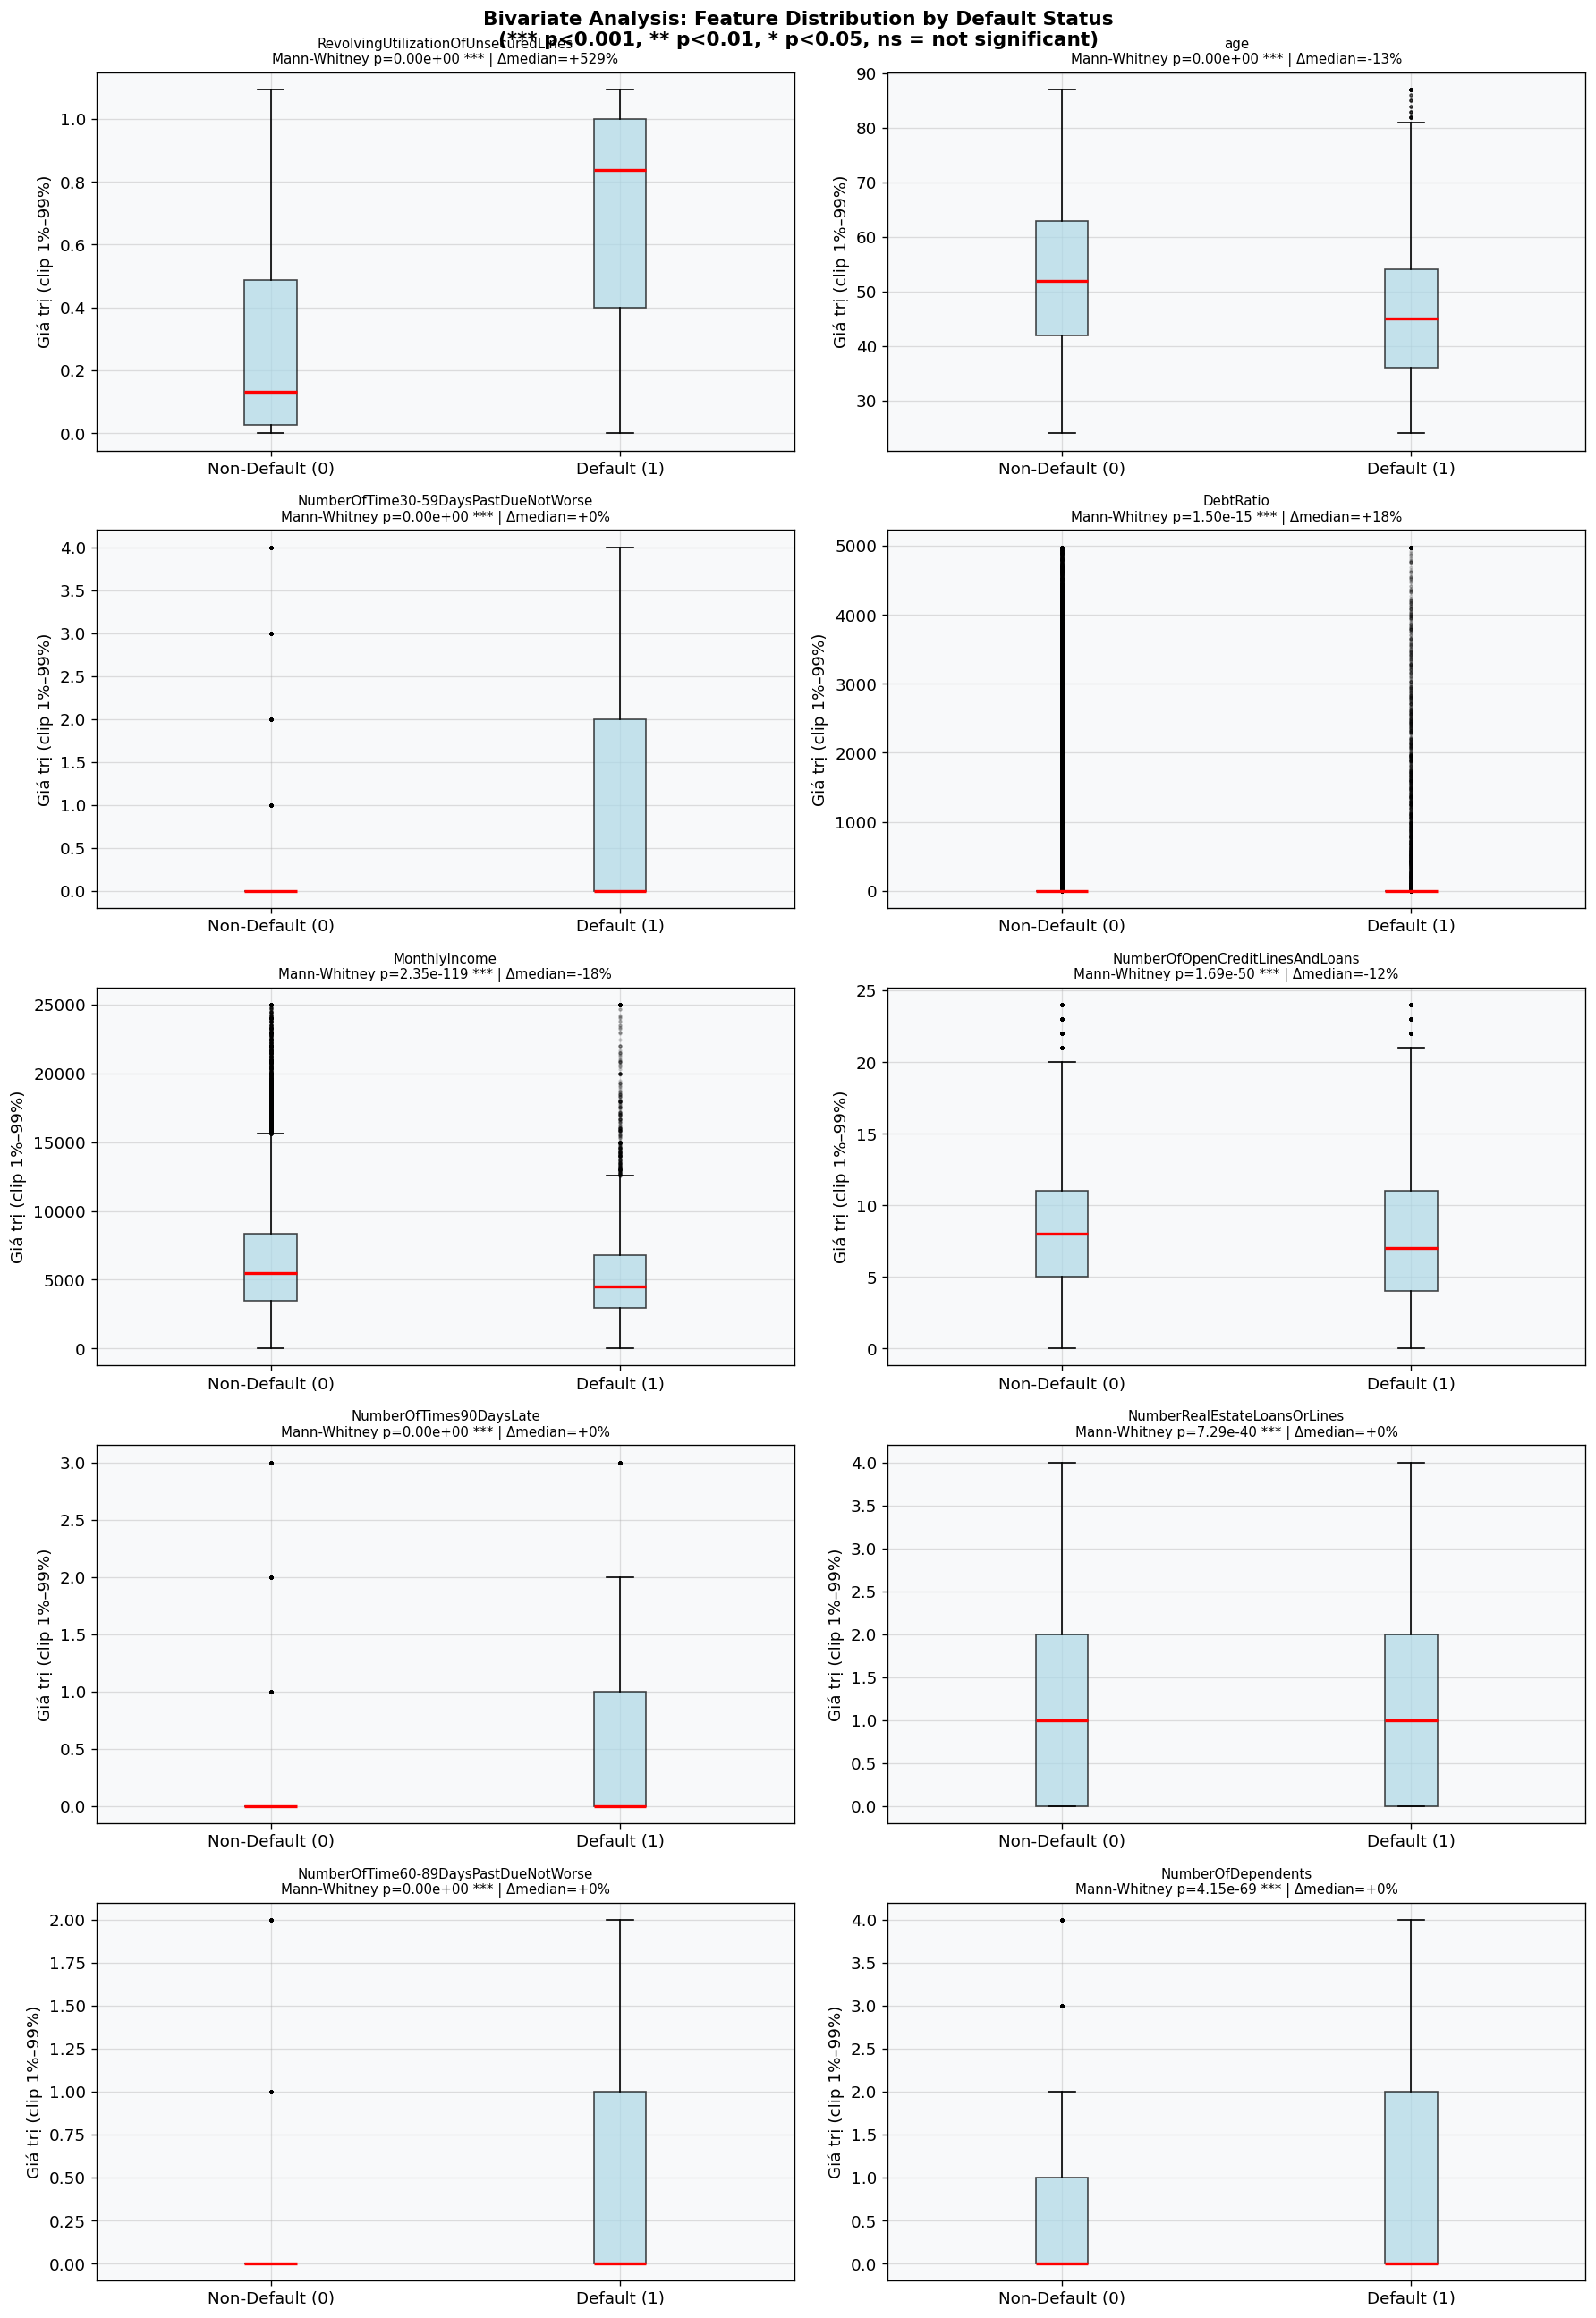

In [9]:
from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(5, 2, figsize=(15, 22))
axes = axes.flatten()

default_mask = df['SeriousDlqin2yrs'] == 1

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data_0 = df.loc[~default_mask, col].dropna()
    data_1 = df.loc[default_mask, col].dropna()

    # Clip for visibility
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)

    ax.boxplot([data_0.clip(p1, p99), data_1.clip(p1, p99)],
               labels=['Non-Default (0)', 'Default (1)'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', alpha=0.2, markersize=3))

    # Mann-Whitney U test
    stat, p_val = mannwhitneyu(data_0, data_1, alternative='two-sided')
    significance = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))

    # Median difference
    med_diff_pct = ((data_1.median() - data_0.median()) / (data_0.median() + 1e-9)) * 100

    ax.set_title(f'{col}\nMann-Whitney p={p_val:.2e} {significance} | Δmedian={med_diff_pct:+.0f}%',
                 fontsize=9)
    ax.set_ylabel('Giá trị (clip 1%–99%)')

plt.suptitle('Bivariate Analysis: Feature Distribution by Default Status\n(*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_04_bivariate_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Correlation Analysis

### 7.1 Pearson vs Spearman

| | Pearson | Spearman |
|---|---|---|
| **Đo** | Tuyến tính | Monotonic (không nhất thiết tuyến tính) |
| **Giả định** | Phân phối chuẩn | Không cần |
| **Phù hợp với** | Features đã chuẩn hóa | Features right-skewed, ordinal |

Với dataset này có nhiều features right-skewed (delinquency counts), **Spearman correlation** là lựa chọn robust hơn.

### 7.2 Multicollinearity concern

Ba features delinquency (`30-59`, `60-89`, `90+`) đều đo lịch sử trễ hạn — có thể tương quan cao với nhau. Multicollinearity không ảnh hưởng Random Forest/XGBoost nhưng làm **hệ số Logistic Regression không ổn định** (high variance of coefficients). Sẽ kiểm tra VIF trong Phase 2.


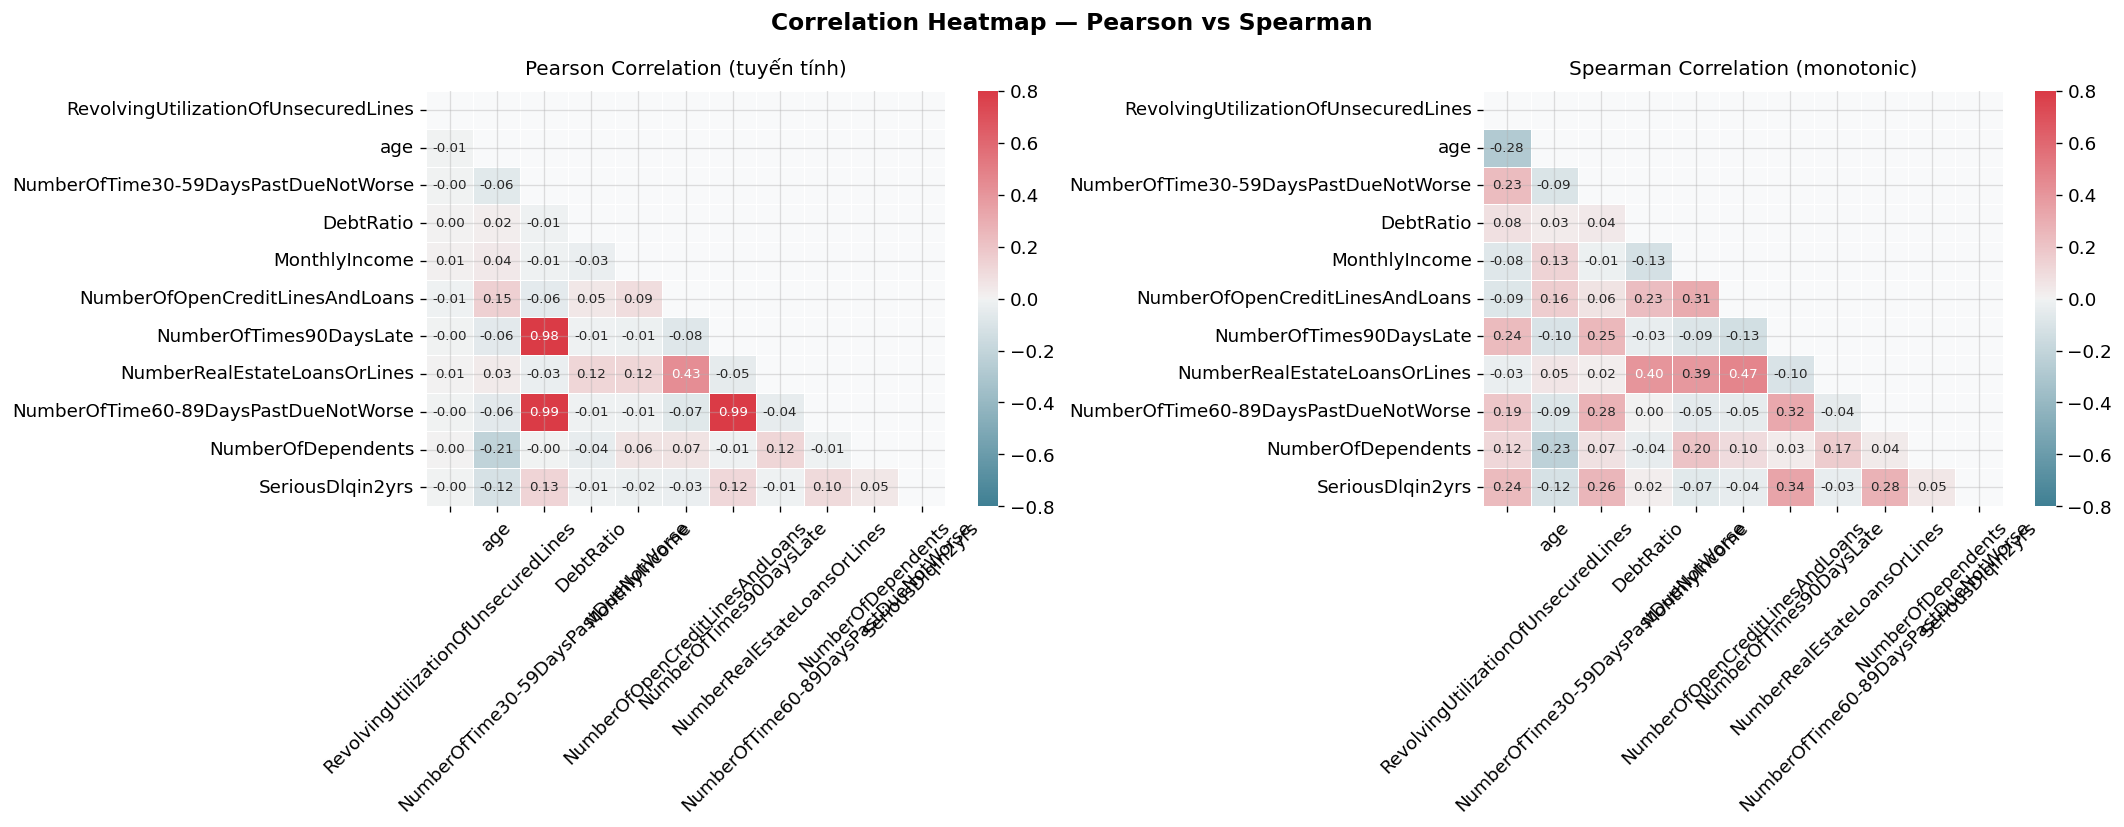

In [10]:
# Pearson và Spearman correlation với target
all_cols = feature_cols + ['SeriousDlqin2yrs']
df_corr = df[all_cols].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, title in zip(axes,
                              ['pearson', 'spearman'],
                              ['Pearson Correlation (tuyến tính)', 'Spearman Correlation (monotonic)']):
    corr = df_corr.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8,
                center=0, annot=True, fmt='.2f', linewidths=0.5,
                annot_kws={'size': 8}, ax=ax)
    ax.set_title(title, fontsize=12, pad=10)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Correlation Heatmap — Pearson vs Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_05_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


Correlation với SeriousDlqin2yrs:
                                       Pearson  Spearman
NumberOfTimes90DaysLate               0.117175  0.342349
NumberOfTime60-89DaysPastDueNotWorse  0.102261  0.277111
NumberOfTime30-59DaysPastDueNotWorse  0.125587  0.257411
RevolvingUtilizationOfUnsecuredLines -0.001802  0.240378
age                                  -0.115386 -0.117034
MonthlyIncome                        -0.019746 -0.066980
NumberOfDependents                    0.046048  0.045972
NumberOfOpenCreditLinesAndLoans      -0.029669 -0.038587
NumberRealEstateLoansOrLines         -0.007038 -0.034118
DebtRatio                            -0.007602  0.020597


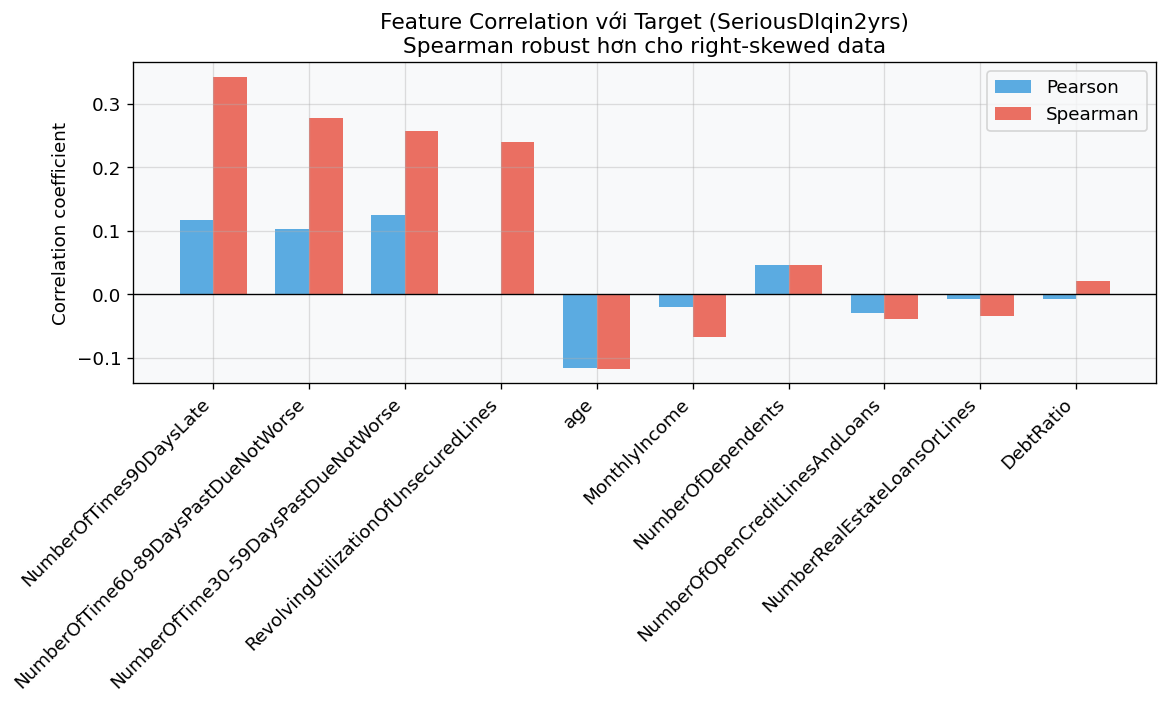

In [11]:
# Top features correlated với target
target_corr_pearson = df[all_cols].corr(method='pearson')['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
target_corr_spearman = df[all_cols].corr(method='spearman')['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')

corr_df = pd.DataFrame({
    'Pearson': target_corr_pearson,
    'Spearman': target_corr_spearman,
    'Abs_Spearman': target_corr_spearman.abs()
}).sort_values('Abs_Spearman', ascending=False)

print("Correlation với SeriousDlqin2yrs:")
print(corr_df.drop('Abs_Spearman', axis=1).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(corr_df))
width = 0.35
ax.bar(x - width/2, corr_df['Pearson'], width, label='Pearson', color='#3498db', alpha=0.8)
ax.bar(x + width/2, corr_df['Spearman'], width, label='Spearman', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(corr_df.index, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Correlation coefficient')
ax.set_title('Feature Correlation với Target (SeriousDlqin2yrs)\nSpearman robust hơn cho right-skewed data')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_06_target_correlation.png', bbox_inches='tight', dpi=150)
plt.show()


## 8.  Delinquency Features

Ba features `30-59`, `60-89`, `90+` days past due hình thành **delinquency tiering** trong credit risk:

| Tier | Feature | Severity | Ý nghĩa |
|------|---------|----------|---------|
| Tier 1 | `30-59 days` | Nhẹ | Bỏ lỡ 1 kỳ thanh toán — có thể do quên hoặc tạm thời hết tiền |
| Tier 2 | `60-89 days` | Trung bình | Bắt đầu vào trạng thái "delinquent" — ngân hàng bắt đầu gọi điện |
| Tier 3 | `90+ days` | Nặng | Gần "charge-off" (xóa nợ) — signal mạnh nhất cho default risk |

Trong FICO score methodology, lần trễ 90+ ngày **gây giảm điểm mạnh nhất** và tồn tại trên credit report 7 năm.

**Hypothesis:** `NumberOfTimes90DaysLate` sẽ là feature có **predictive power cao nhất** trong dataset này.


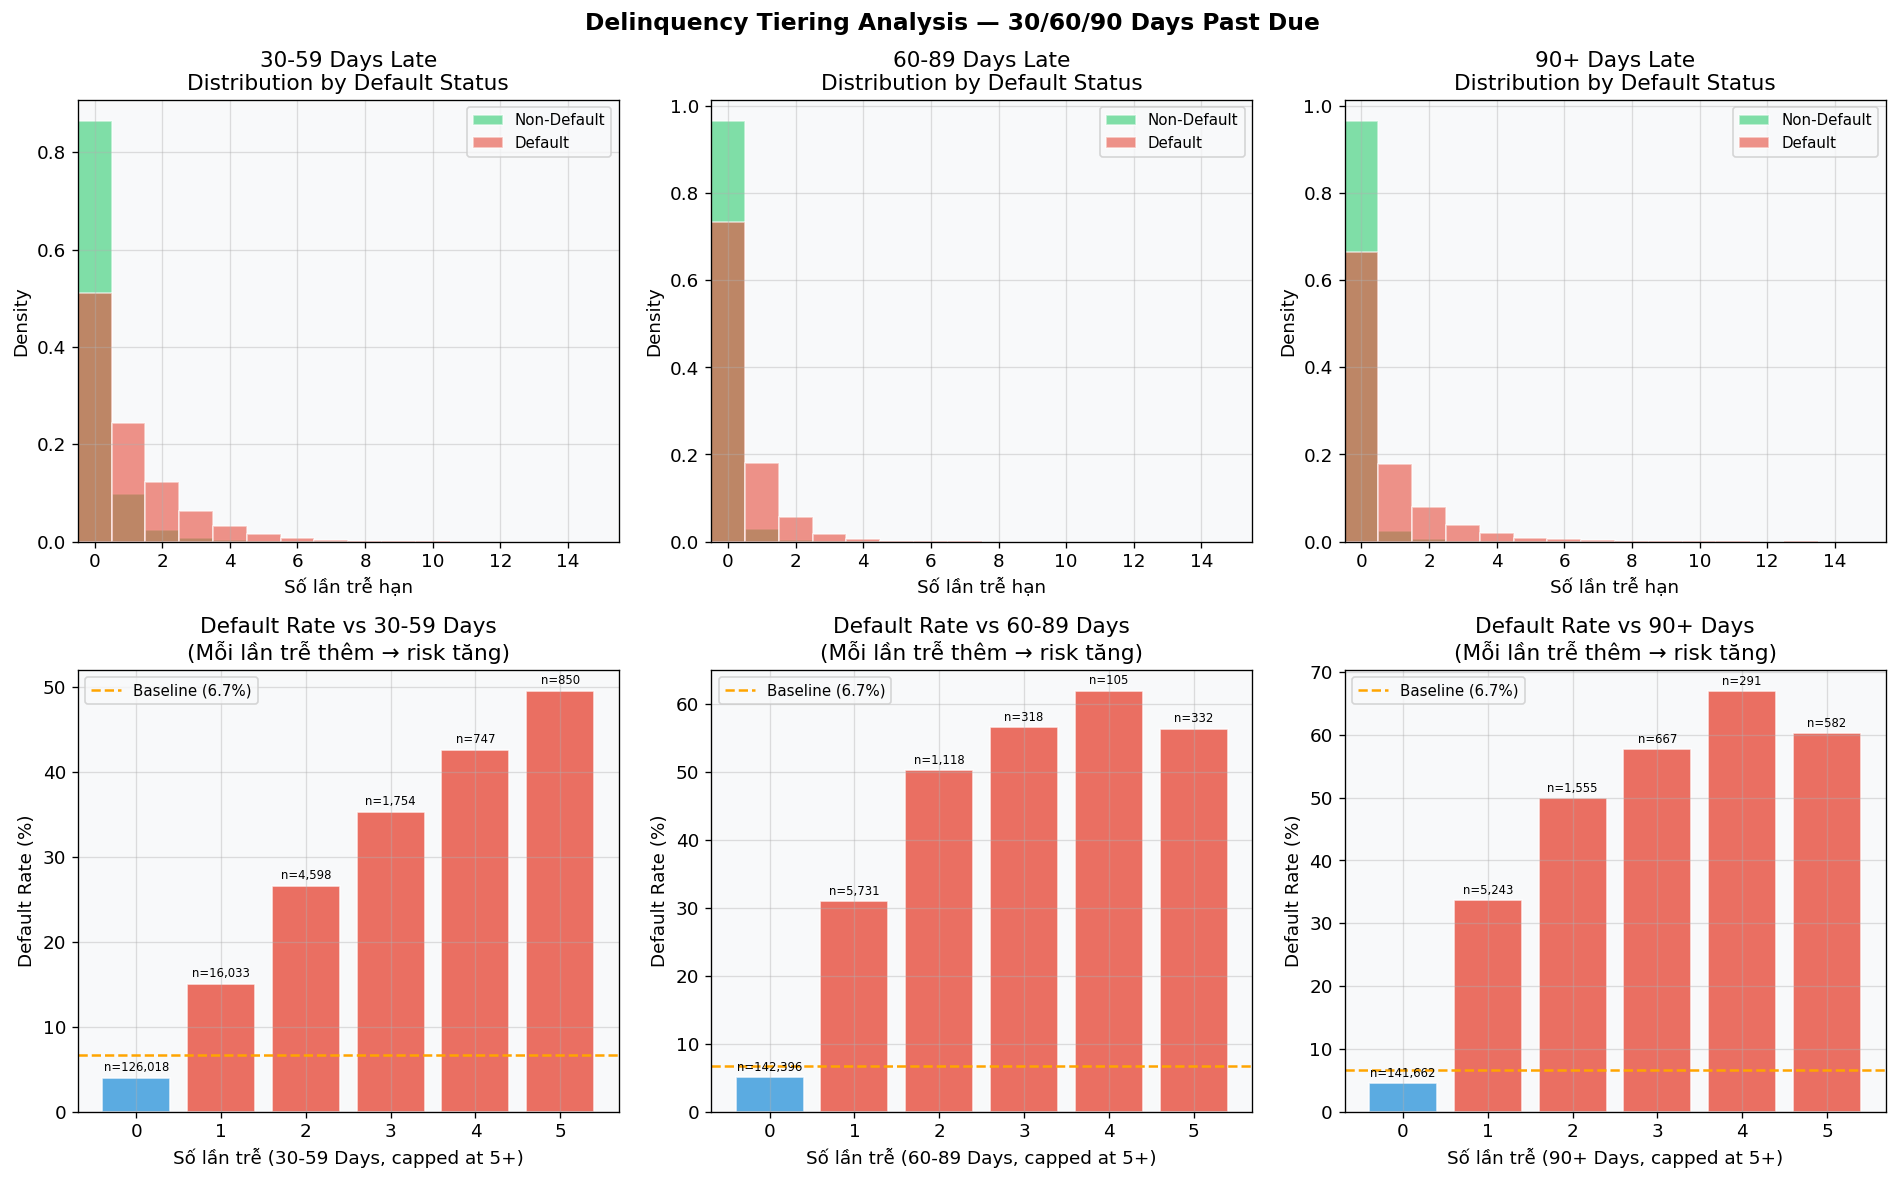

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Row 1: Distribution by default status
for i, col in enumerate(delinq_cols):
    ax = axes[0, i]
    short_name = {
        'NumberOfTime30-59DaysPastDueNotWorse': '30-59 Days Late',
        'NumberOfTime60-89DaysPastDueNotWorse': '60-89 Days Late',
        'NumberOfTimes90DaysLate': '90+ Days Late'
    }[col]

    max_val = min(df[col].quantile(0.999), 15)
    bins = np.arange(0, max_val + 1) - 0.5

    for label, color, name in [(0, PALETTE['non_default'], 'Non-Default'),
                                 (1, PALETTE['default'], 'Default')]:
        data = df.loc[df['SeriousDlqin2yrs'] == label, col].clip(0, max_val)
        ax.hist(data, bins=bins, density=True, alpha=0.6, color=color, label=name, edgecolor='white')

    ax.set_title(f'{short_name}\nDistribution by Default Status')
    ax.set_xlabel('Số lần trễ hạn')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, max_val + 0.5)

# Row 2: Default rate by delinquency count
for i, col in enumerate(delinq_cols):
    ax = axes[1, i]
    short_name = {
        'NumberOfTime30-59DaysPastDueNotWorse': '30-59 Days',
        'NumberOfTime60-89DaysPastDueNotWorse': '60-89 Days',
        'NumberOfTimes90DaysLate': '90+ Days'
    }[col]

    # Default rate vs count (cap at 5 for visibility)
    df_temp = df[[col, 'SeriousDlqin2yrs']].copy()
    df_temp[col] = df_temp[col].clip(0, 5)
    default_rate = df_temp.groupby(col)['SeriousDlqin2yrs'].agg(['mean', 'count']).reset_index()
    default_rate.columns = [col, 'default_rate', 'count']
    default_rate['default_rate'] *= 100

    bars = ax.bar(default_rate[col], default_rate['default_rate'],
                  color=[PALETTE['default'] if r > 10 else PALETTE['neutral']
                         for r in default_rate['default_rate']],
                  alpha=0.8, edgecolor='white')
    ax.axhline(y=6.7, color='orange', linestyle='--', linewidth=1.5,
               label='Baseline (6.7%)')
    ax.set_xlabel(f'Số lần trễ ({short_name}, capped at 5+)')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title(f'Default Rate vs {short_name}\n(Mỗi lần trễ thêm → risk tăng)')
    ax.legend(fontsize=9)

    # Count annotations
    for bar, row in zip(bars, default_rate.itertuples()):
        if row.count > 100:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'n={row.count:,}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Delinquency Tiering Analysis — 30/60/90 Days Past Due',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_07_delinquency_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Credit Utilization Analysis

`RevolvingUtilizationOfUnsecuredLines` là **tỷ lệ sử dụng hạn mức tín dụng xoay vòng** (thẻ tín dụng, credit lines) so với tổng hạn mức được cấp.

**Credit scoring context:**
- < 30%: Tốt — quản lý tín dụng có kiểm soát
- 30–60%: Trung bình — bắt đầu có dấu hiệu phụ thuộc tín dụng
- 60–90%: Xấu — "credit-dependent", đang cần tiền
- > 100%: Anomaly — vượt hạn mức (có thể do phí, lãi, hoặc data error)

**Hypothesis:** Utilization cao → default risk cao. Đây là một trong những features quan trọng nhất trong FICO score (chiếm ~30% tổng điểm).


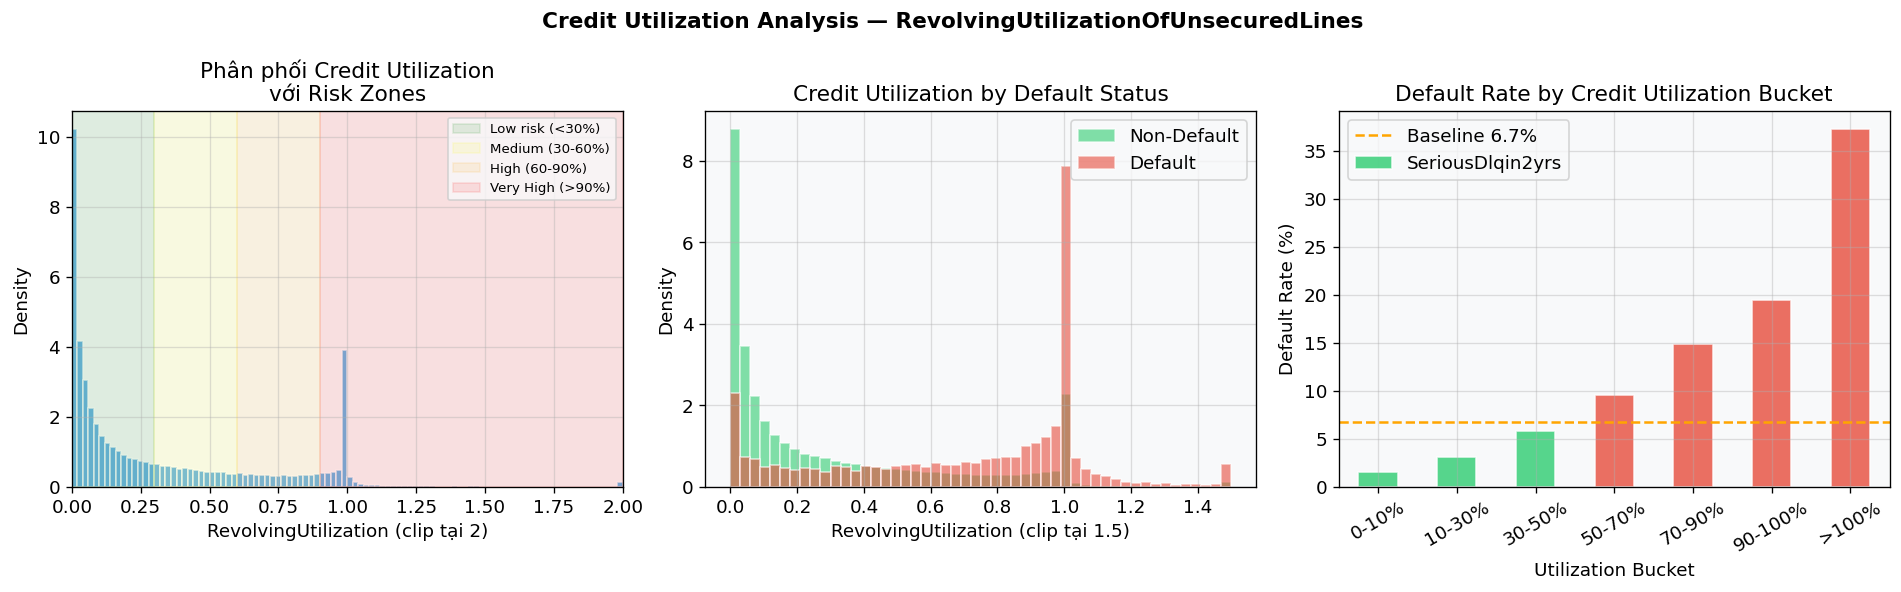

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram với risk zones
ax = axes[0]
util = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 2)

ax.hist(util, bins=100, color=PALETTE['neutral'], alpha=0.7, edgecolor='white', density=True)
# Risk zones
ax.axvspan(0, 0.3, alpha=0.1, color='green', label='Low risk (<30%)')
ax.axvspan(0.3, 0.6, alpha=0.1, color='yellow', label='Medium (30-60%)')
ax.axvspan(0.6, 0.9, alpha=0.1, color='orange', label='High (60-90%)')
ax.axvspan(0.9, 2.0, alpha=0.1, color='red', label='Very High (>90%)')
ax.set_xlim(0, 2)
ax.set_xlabel('RevolvingUtilization (clip tại 2)')
ax.set_ylabel('Density')
ax.set_title('Phân phối Credit Utilization\nvới Risk Zones')
ax.legend(fontsize=8)

# By default status
ax = axes[1]
for label, color, name in [(0, PALETTE['non_default'], 'Non-Default'), (1, PALETTE['default'], 'Default')]:
    data = df.loc[df['SeriousDlqin2yrs'] == label, 'RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5)
    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_xlabel('RevolvingUtilization (clip tại 1.5)')
ax.set_ylabel('Density')
ax.set_title('Credit Utilization by Default Status')
ax.legend()

# Default rate by utilization bucket
ax = axes[2]
df_util = df[['RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs']].copy()
df_util['util_bucket'] = pd.cut(
    df_util['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5),
    bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.5],
    labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%', '>100%']
)
rate_by_bucket = df_util.groupby('util_bucket', observed=True)['SeriousDlqin2yrs'].mean() * 100
rate_by_bucket.plot(kind='bar', ax=ax,
                    color=[PALETTE['non_default'] if r < 6.7 else PALETTE['default'] for r in rate_by_bucket.values],
                    alpha=0.8, edgecolor='white')
ax.axhline(y=6.7, color='orange', linestyle='--', linewidth=1.5, label='Baseline 6.7%')
ax.set_xlabel('Utilization Bucket')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Credit Utilization Bucket')
ax.legend()
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Credit Utilization Analysis — RevolvingUtilizationOfUnsecuredLines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_08_credit_utilization.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. Age Distribution Analysis

**Domain context:**
- Người trẻ (<25): Ít lịch sử tín dụng (thin file), thu nhập thấp/không ổn định → risk cao
- Người trung niên (35-55): Ở đỉnh thu nhập, tích lũy được → risk thấp nhất
- Người cao tuổi (>65): Thu nhập cố định (pension), ít nợ → risk thấp hơn trung bình

**Anomaly cần xử lý:** `age == 0` là data error cần loại bỏ hoàn toàn.


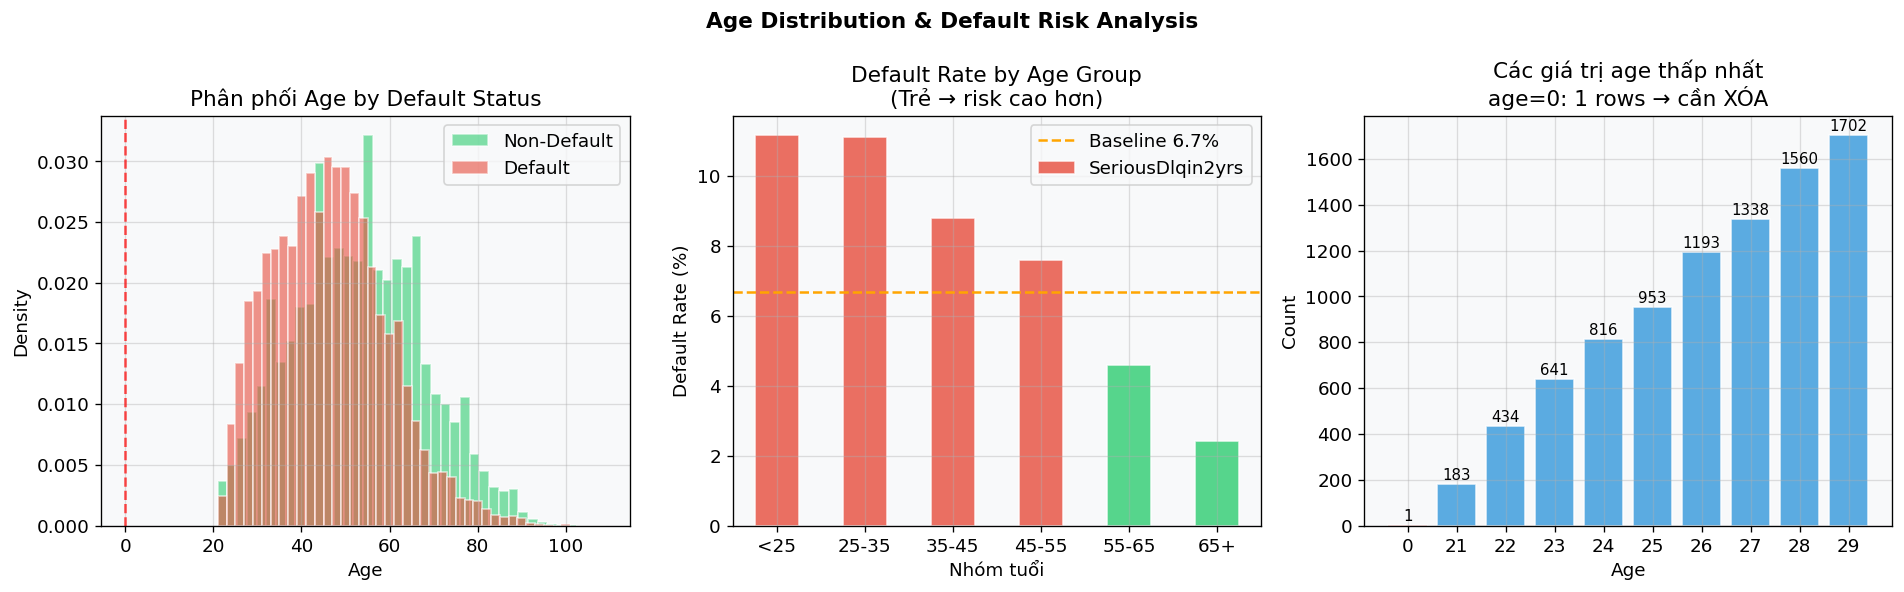

age == 0: 1 rows sẽ bị XÓA trong Phase 2 (nonsensical)
Sau khi xóa: 149999 rows


In [14]:
age_valid = df[df['age'] > 0]  # Loại bỏ age=0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
ax = axes[0]
for label, color, name in [(0, PALETTE['non_default'], 'Non-Default'), (1, PALETTE['default'], 'Default')]:
    data = age_valid.loc[age_valid['SeriousDlqin2yrs'] == label, 'age']
    ax.hist(data, bins=40, density=True, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Phân phối Age by Default Status')
ax.legend()
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='age=0 (error, đã loại)')

# Default rate by age group
ax = axes[1]
age_valid_temp = age_valid[['age', 'SeriousDlqin2yrs']].copy()
age_valid_temp['age_group'] = pd.cut(age_valid_temp['age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])
rate_by_age = age_valid_temp.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100
colors = [PALETTE['default'] if r > 6.7 else PALETTE['non_default'] for r in rate_by_age.values]
rate_by_age.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(y=6.7, color='orange', linestyle='--', linewidth=1.5, label='Baseline 6.7%')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Age Group\n(Trẻ → risk cao hơn)')
ax.legend()
ax.tick_params(axis='x', rotation=0)

# age == 0 detail
ax = axes[2]
age_zero_count = (df['age'] == 0).sum()
age_dist = df['age'].value_counts().sort_index().head(10)
ax.bar(age_dist.index.astype(str), age_dist.values,
       color=[PALETTE['default'] if v == 0 else PALETTE['neutral'] for v in age_dist.index],
       alpha=0.8, edgecolor='white')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title(f'Các giá trị age thấp nhất\nage=0: {age_zero_count} rows → cần XÓA')
for i, (idx, val) in enumerate(age_dist.items()):
    ax.text(i, val + 5, str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Age Distribution & Default Risk Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_09_age_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"age == 0: {age_zero_count} rows sẽ bị XÓA trong Phase 2 (nonsensical)")
print(f"Sau khi xóa: {len(df) - age_zero_count} rows")


## 11. DebtRatio & MonthlyIncome Analysis

### DebtRatio (DTI Proxy)

`DebtRatio = Tổng nợ hàng tháng / Thu nhập hàng tháng` — tương đương **Debt-to-Income (DTI) ratio** trong thẩm định tín dụng.

**Tiêu chuẩn ngân hàng:**
- DTI < 36%: Lý tưởng — còn nhiều thu nhập tự do
- DTI 36-50%: Cảnh báo — khó khăn nếu có thêm chi phí
- DTI > 50%: Rủi ro cao — phần lớn thu nhập dùng trả nợ

**Caveat:** Trong dataset này, `DebtRatio` có nhiều giá trị cực lớn (>1000) — có thể là DTI thực tế hoặc data entry error khi income ≈ 0.

### MonthlyIncome

Income là denominator trong DTI. Khi income = 0 hoặc missing, DebtRatio trở nên vô nghĩa. Đây là lý do cần **impute MonthlyIncome trước** khi tính AbsoluteMonthlyDebt absolute.


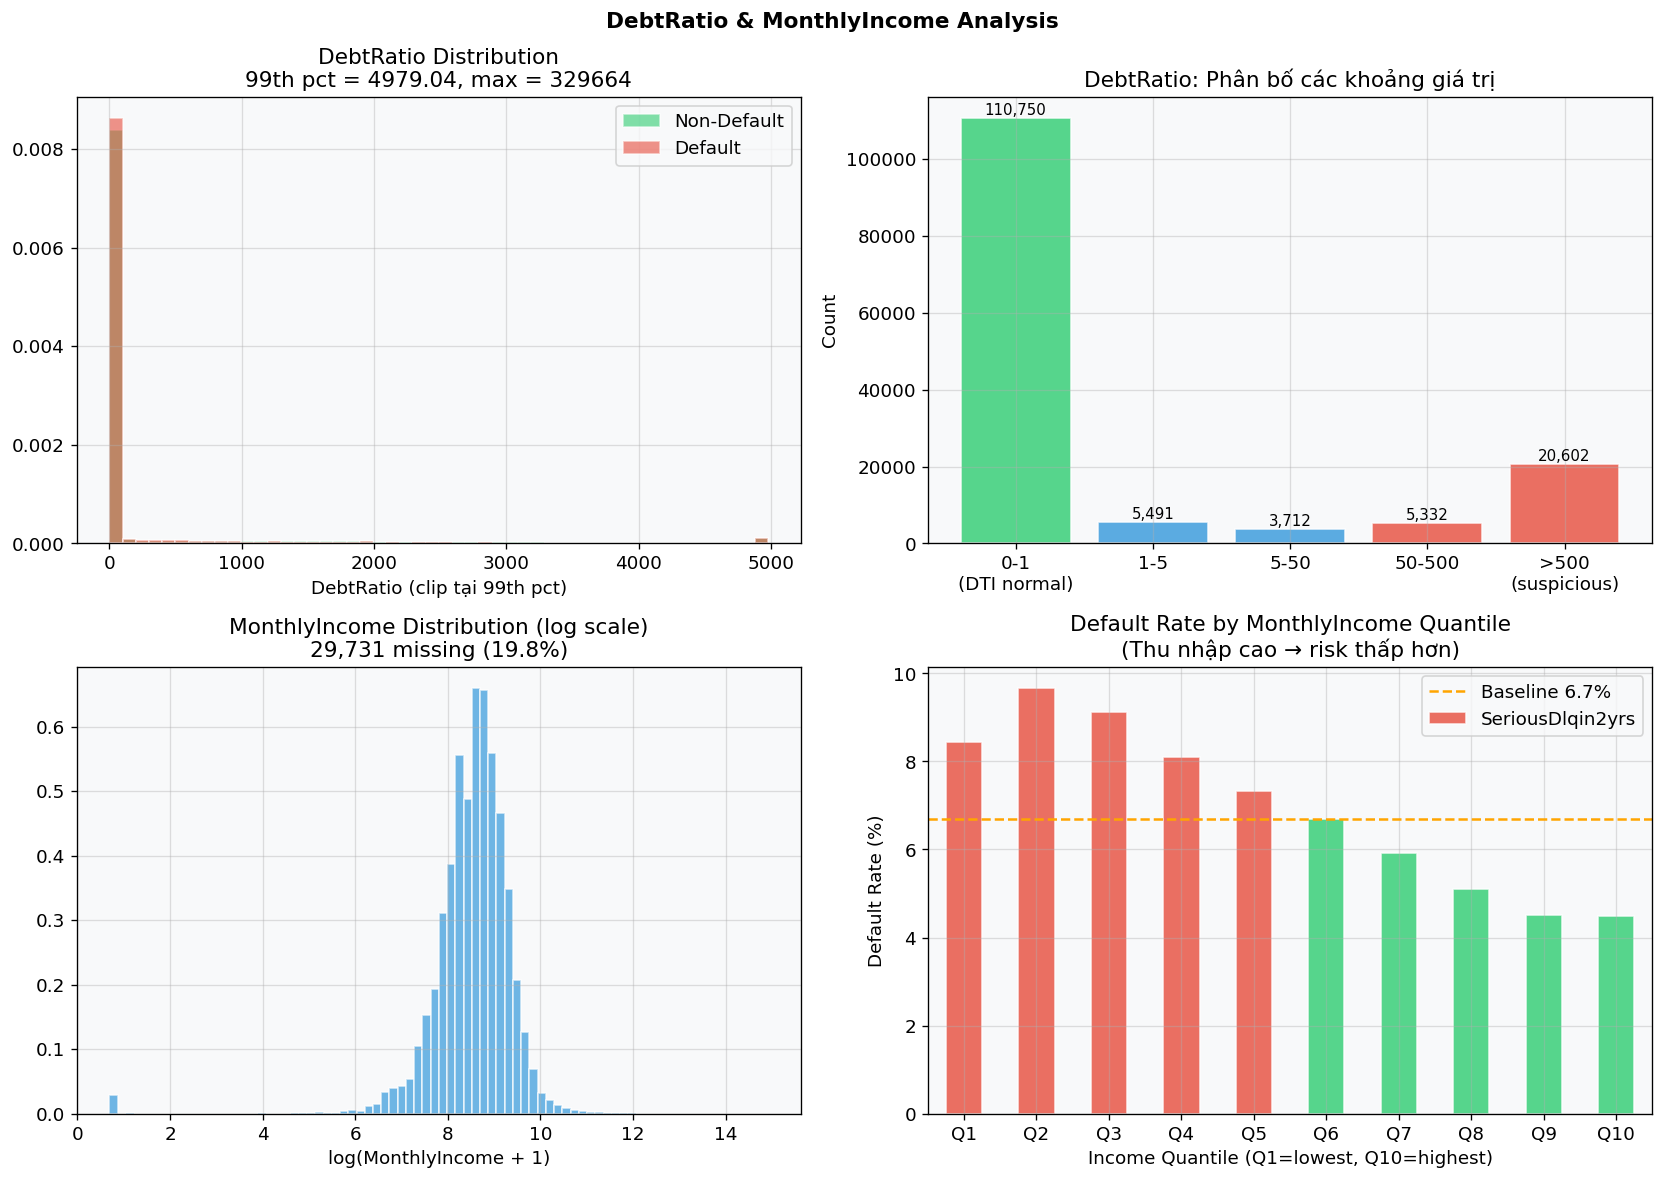

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DebtRatio distribution (capped)
ax = axes[0, 0]
debt_capped = df['DebtRatio'].clip(0, df['DebtRatio'].quantile(0.99))
for label, color, name in [(0, PALETTE['non_default'], 'Non-Default'), (1, PALETTE['default'], 'Default')]:
    data = df.loc[df['SeriousDlqin2yrs'] == label, 'DebtRatio'].clip(0, df['DebtRatio'].quantile(0.99))
    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_xlabel('DebtRatio (clip tại 99th pct)')
ax.set_title(f"DebtRatio Distribution\n99th pct = {df['DebtRatio'].quantile(0.99):.2f}, max = {df['DebtRatio'].max():.0f}")
ax.legend()

# DebtRatio extreme values
ax = axes[0, 1]
debt_ranges = ['0-1\n(DTI normal)', '1-5', '5-50', '50-500', '>500\n(suspicious)']
debt_bins = [0, 1, 5, 50, 500, float('inf')]
counts = []
for lo, hi in zip(debt_bins[:-1], debt_bins[1:]):
    if hi == float('inf'):
        counts.append((df['DebtRatio'] > lo).sum())
    else:
        counts.append(((df['DebtRatio'] > lo) & (df['DebtRatio'] <= hi)).sum())
bars = ax.bar(debt_ranges, counts,
              color=[PALETTE['non_default'], PALETTE['neutral'], PALETTE['neutral'],
                     PALETTE['default'], PALETTE['default']],
              alpha=0.8, edgecolor='white')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{c:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('DebtRatio: Phân bố các khoảng giá trị')

# MonthlyIncome distribution (log scale)
ax = axes[1, 0]
income_valid = df['MonthlyIncome'].dropna()
income_pos = income_valid[income_valid > 0]
ax.hist(np.log1p(income_pos), bins=80, color=PALETTE['neutral'], alpha=0.7, edgecolor='white', density=True)
ax.set_xlabel('log(MonthlyIncome + 1)')
ax.set_title(f'MonthlyIncome Distribution (log scale)\n{df["MonthlyIncome"].isnull().sum():,} missing ({df["MonthlyIncome"].isnull().mean()*100:.1f}%)')

# Default rate by income quantile
ax = axes[1, 1]
df_inc = df[['MonthlyIncome', 'SeriousDlqin2yrs']].dropna()
df_inc['income_quantile'] = pd.qcut(df_inc['MonthlyIncome'], q=10, labels=[f'Q{i}' for i in range(1, 11)])
rate_by_quantile = df_inc.groupby('income_quantile', observed=True)['SeriousDlqin2yrs'].mean() * 100
colors = [PALETTE['default'] if r > 6.7 else PALETTE['non_default'] for r in rate_by_quantile.values]
rate_by_quantile.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(y=6.7, color='orange', linestyle='--', label='Baseline 6.7%')
ax.set_xlabel('Income Quantile (Q1=lowest, Q10=highest)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by MonthlyIncome Quantile\n(Thu nhập cao → risk thấp hơn)')
ax.legend()
ax.tick_params(axis='x', rotation=0)

plt.suptitle('DebtRatio & MonthlyIncome Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_10_debt_income.png', bbox_inches='tight', dpi=150)
plt.show()


## 12. Tổng hợp Key Insights EDA

### Findings & Actions cho Bước kế tiếp

| # | Finding | Mức độ | Actions cho Bước kế tiếp |
|---|---------|--------|---------------------|
| 1 | `age == 0`: data error | Critical | **XÓA** toàn bộ rows có age=0 |
| 2 | `MonthlyIncome`: 19.82% missing, là MAR/MNAR | High | **KNN Imputer** (k=5), không dùng median đơn giản |
| 3 | `NumberOfDependents`: 2.62% missing | Medium | **Median Imputation** đủ |
| 4 | `RevolvingUtilization > 10`: extreme outlier | High | **Capping** tại 99th percentile |
| 5 | `MonthlyIncome > 99th pct`: potential outlier | Medium | **Capping** tại 99th percentile |
| 6 | Delinquency counts có giá trị cực lớn | Medium | **Capping** tại giá trị hợp lý |
| 7 | Class imbalance 6.7% | Critical | **AUC-ROC** là primary metric; thử `class_weight='balanced'` và SMOTE |
| 8 | `NumberOfTimes90DaysLate` có correlation cao nhất với target | High | Feature quan trọng nhất trong TotalDelinquencyScore |
| 9 | `RevolvingUtilization` là predictor thứ 2 | Medium | Thành phần của FinancialStressIndex |
| 10 | DebtRatio có outlier cực lớn (>500), vô nghĩa khi income~0 | Medium | Cần thận trọng khi tính DTI absolute |

### Features quan trọng nhất (dự đoán dựa trên EDA):
1. `NumberOfTimes90DaysLate` — severe delinquency history (strongest signal)
2. `RevolvingUtilizationOfUnsecuredLines` — financial stress indicator
3. `NumberOfTime30-59DaysPastDueNotWorse` — delinquency pattern
4. `age` — life stage & financial experience proxy
5. `MonthlyIncome` — capacity to repay

### Feature Engineering cần làm :
- `TotalDelinquencyScore` = 3×(90+) + 2×(60-89) + 1×(30-59): weighted severity
- `FinancialStressIndex` = Utilization × TotalDelinquencyScore: multiplicative risk signal
- `AbsoluteMonthlyDebt` = DebtRatio × MonthlyIncome: absolute DTI
- `DelinquencyTrend` = (30-59) - (90+): trajectory of financial health


In [16]:
# Final quantitative summary for Phase 2
print("=" * 60)
print("EDA SUMMARY — LOAN DEFAULT PREDICTION")
print("=" * 60)
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target: {df['SeriousDlqin2yrs'].sum():,} defaults ({df['SeriousDlqin2yrs'].mean()*100:.2f}%)")
print()
print("Missing Values:")
print(f"  MonthlyIncome:    {df['MonthlyIncome'].isnull().sum():,} ({df['MonthlyIncome'].isnull().mean()*100:.2f}%)")
print(f"  NumberOfDependents: {df['NumberOfDependents'].isnull().sum():,} ({df['NumberOfDependents'].isnull().mean()*100:.2f}%)")
print()
print("Outliers to treat in Phase 2:")
print(f"  age == 0:         {(df['age'] == 0).sum()} rows → DELETE")
print(f"  Util > 99th pct:  {(df['RevolvingUtilizationOfUnsecuredLines'] > df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)).sum()} rows → CAP")
print(f"  Income > 99th pct: {(df['MonthlyIncome'] > df['MonthlyIncome'].quantile(0.99)).sum()} rows → CAP")
print()
print("Top correlations với target (Spearman):")
corr_spearman = df.corr(method='spearman', numeric_only=True)['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
for feat, val in corr_spearman.abs().sort_values(ascending=False).head(5).items():
    sign = '+' if corr_spearman[feat] > 0 else '-'
    print(f"  {feat}: {sign}{val:.4f}")
print()
print("Figures saved to reports/")


EDA SUMMARY — LOAN DEFAULT PREDICTION
Dataset: 150,000 rows × 11 columns
Target: 10,026 defaults (6.68%)

Missing Values:
  MonthlyIncome:    29,731 (19.82%)
  NumberOfDependents: 3,924 (2.62%)

Outliers to treat in Phase 2:
  age == 0:         1 rows → DELETE
  Util > 99th pct:  1500 rows → CAP
  Income > 99th pct: 1168 rows → CAP

Top correlations với target (Spearman):


  NumberOfTimes90DaysLate: +0.3423
  NumberOfTime60-89DaysPastDueNotWorse: +0.2771
  NumberOfTime30-59DaysPastDueNotWorse: +0.2574
  RevolvingUtilizationOfUnsecuredLines: +0.2404
  age: -0.1170

Figures saved to reports/
